In [74]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import os

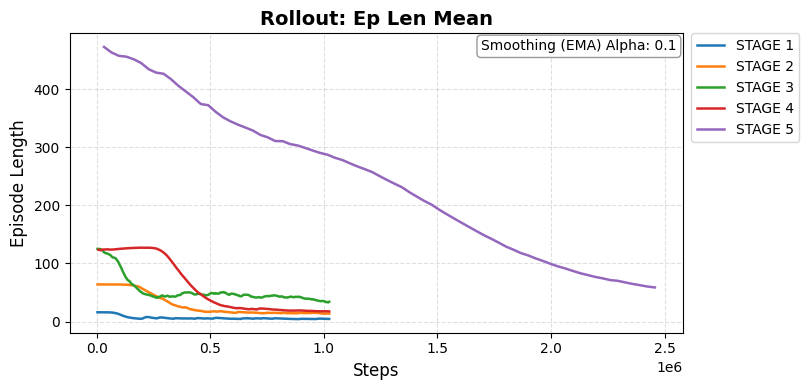

Generated: rollout_ep_len_mean.png


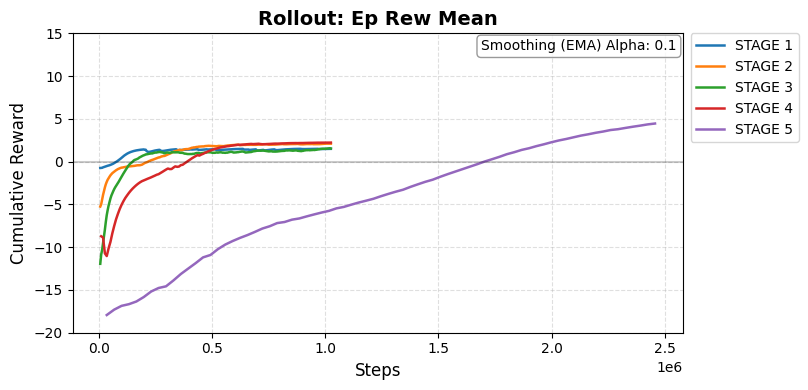

Generated: rollout_ep_rew_mean.png


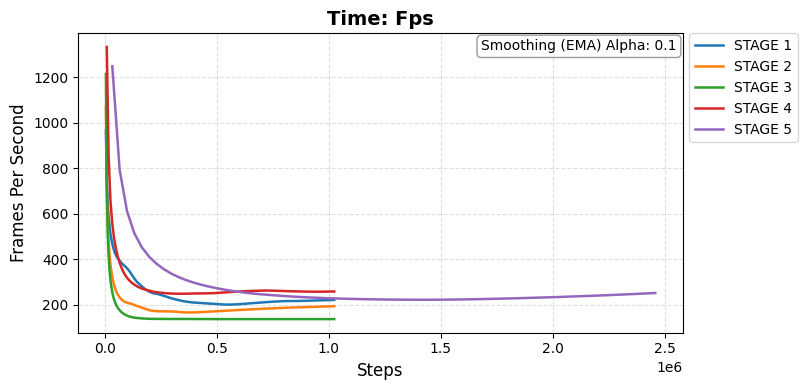

Generated: time_fps.png


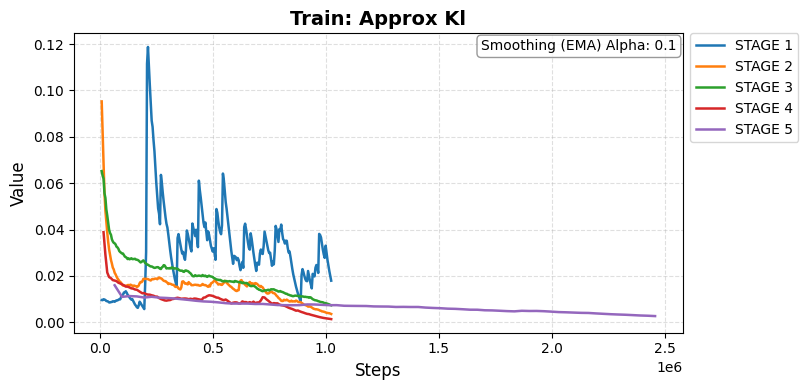

Generated: train_approx_kl.png


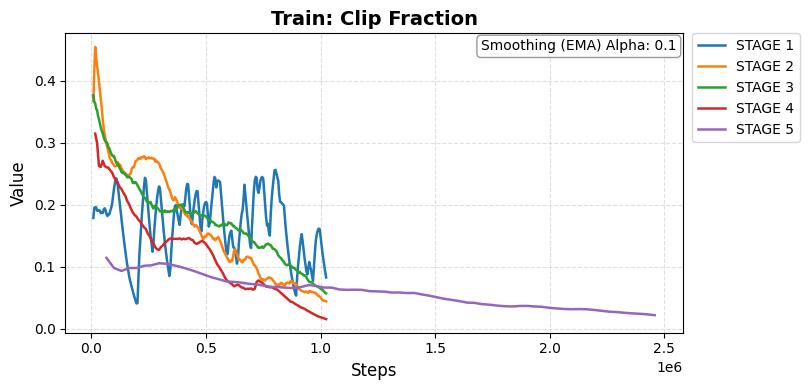

Generated: train_clip_fraction.png


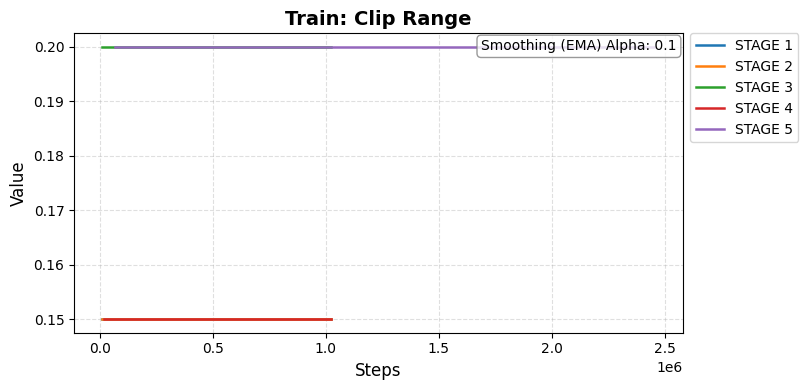

Generated: train_clip_range.png


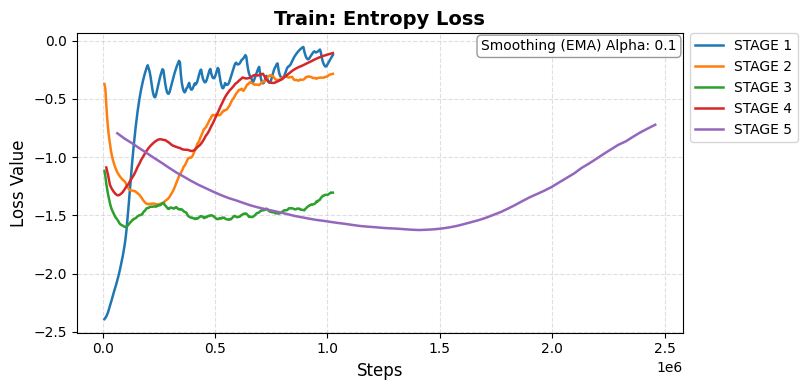

Generated: train_entropy_loss.png


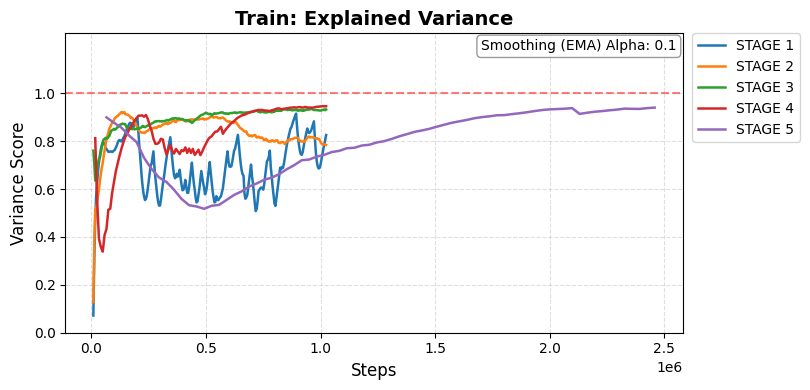

Generated: train_explained_variance.png


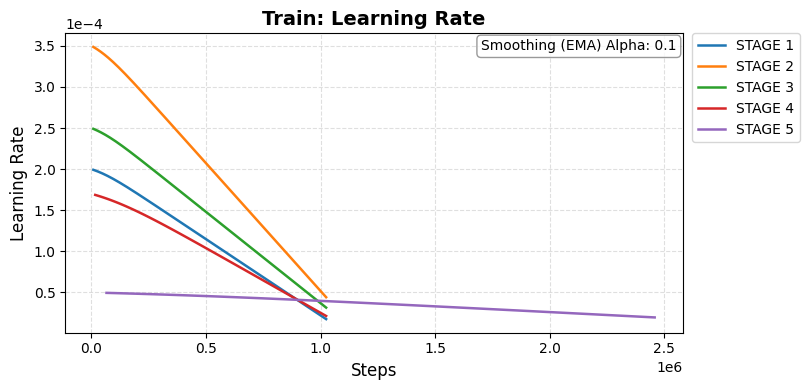

Generated: train_learning_rate.png


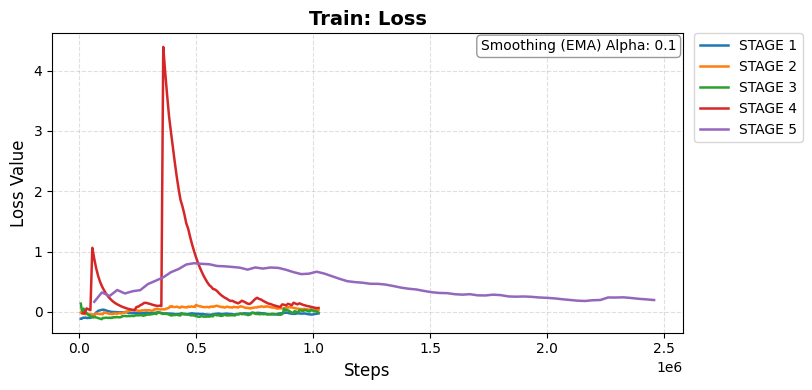

Generated: train_loss.png


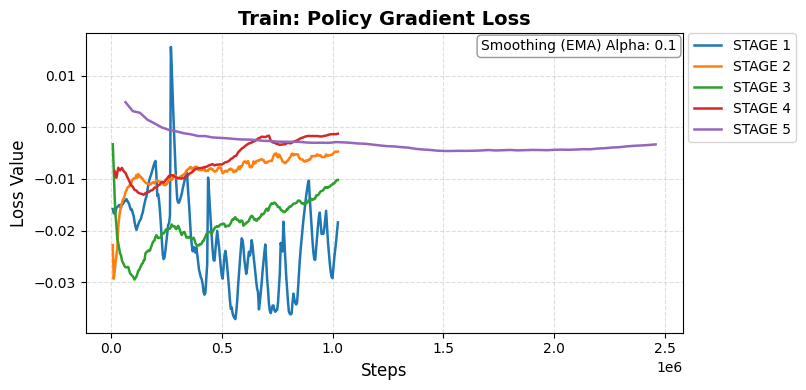

Generated: train_policy_gradient_loss.png


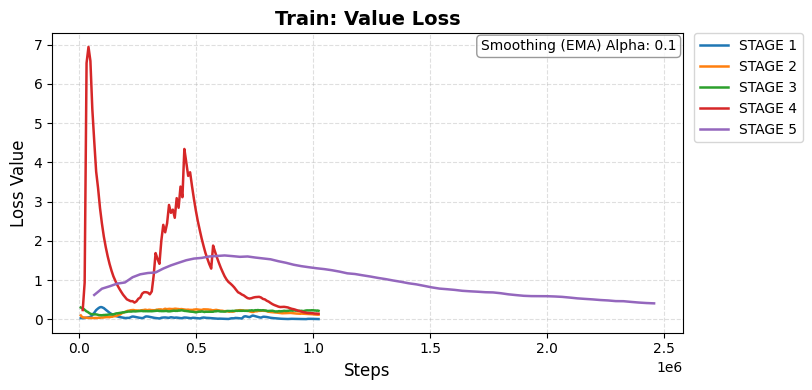

Generated: train_value_loss.png


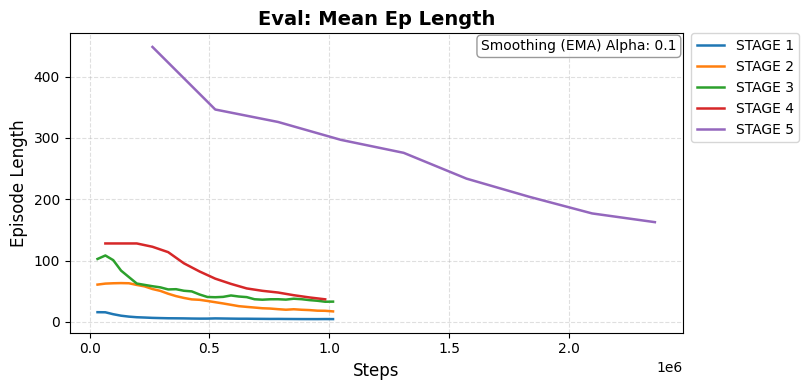

Generated: eval_mean_ep_length.png


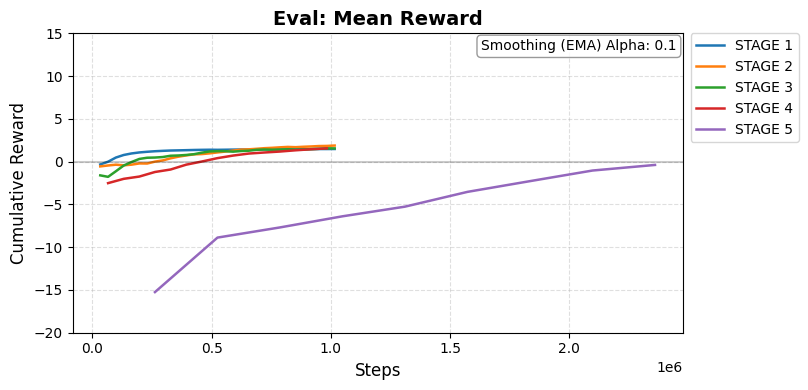

Generated: eval_mean_reward.png


In [15]:
log_base_dir = "./"  
stages = ["STAGE 1", "STAGE 2", "STAGE 3", "STAGE 4", "STAGE 5"]
metrics = [
    'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 
    'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 
    'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 
    'train/loss', 'train/policy_gradient_loss', 'train/value_loss', 
    'eval/mean_ep_length', 'eval/mean_reward'
]

y_labels = {
    "ep_len_mean": "Episode Length",
    "mean_ep_length": "Episode Length",
    "rew_mean": "Cumulative Reward",
    "mean_reward": "Cumulative Reward",
    "fps": "Frames Per Second",
    "loss": "Loss Value",
    "learning_rate": "Learning Rate",
    "explained_variance": "Variance Score"
}


SMOOTHING_ALPHA = 0.1

output_dir = "exported_plots_annotated"
os.makedirs(output_dir, exist_ok=True)

def get_data(stage_path, tag):
    try:
        ea = event_accumulator.EventAccumulator(stage_path)
        ea.Reload()
        if tag in ea.Tags()['scalars']:
            events = ea.Scalars(tag)
            return pd.DataFrame([(e.step, e.value) for e in events], columns=['step', 'value'])
    except Exception:
        pass
    return pd.DataFrame()

# --- Plotting Loop ---
for metric in metrics:
    plt.figure(figsize=(10, 4))
    clean_title = metric.replace('/', ': ').replace('_', ' ').title()

    is_reward_plot = "rew_mean" in metric or "mean_reward" in metric
    
    for stage in stages:
        path = os.path.join(log_base_dir, stage)
        df = get_data(path, metric)
        
        if not df.empty:
            # Applying Smoothing Exponential Moving Average
            df['smoothed'] = df['value'].ewm(alpha=SMOOTHING_ALPHA).mean()
            plt.plot(df['step'], df['smoothed'], label=stage, linewidth=1.8)

    y_label = "Value"  # Default
    for key, label in y_labels.items():
        if key in metric:
            y_label = label
            break
        else:
            y_label = "Value"

    
    plt.title(clean_title, fontsize=14, fontweight='bold')
    plt.xlabel("Steps", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)


    plt.legend(bbox_to_anchor=(1.19, 1.0), loc='upper right', borderaxespad=0.)



    text_str = f"Smoothing (EMA) Alpha: {SMOOTHING_ALPHA}"
    plt.text(0.99, 0.98, text_str, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    if is_reward_plot:
        plt.ylim(-20, 15)
        plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)

    if "explained_variance" in metric:
        plt.ylim(0, 1.25)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)

    if "learning_rate" in metric:
        plt.ylabel("Learning Rate", fontsize=12)
        formatter = ScalarFormatter(useMathText=False)
        formatter.set_scientific(True)
        formatter.set_powerlimits((-1, 1))
        plt.gca().yaxis.set_major_formatter(formatter)

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    file_name = metric.replace('/', '_') + ".png"
    plt.savefig(os.path.join(output_dir, file_name), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Generated: {file_name}")

# Calculating ML evaluation graph and qudrant

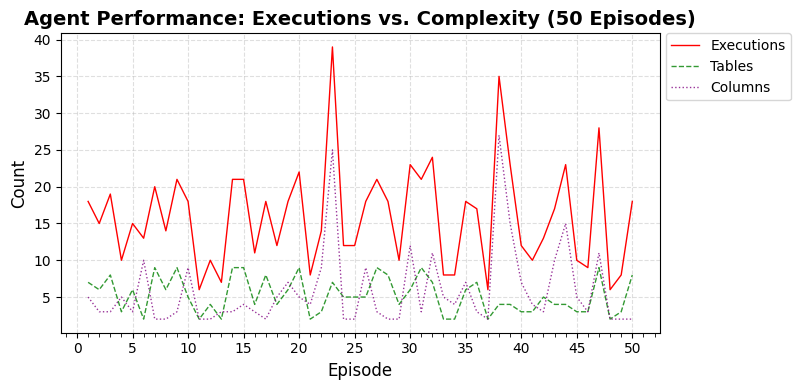

In [ ]:
input_file = r"\model\eval_logs\20260309_124357_v0.7.1_eval_stage_6.csv"

input_file = r"\model\eval_logs\20260309_124357_v0.7.1_eval_stage_6.csv"

# import the data
df = pd.read_csv(input_file)

plt.figure(figsize=(10, 4))

plt.plot(df['episode'], df['executes'], label='Executions', color='red', linewidth=1)
plt.plot(df['episode'], df['tables'], label='Tables', color='green', linestyle='--', linewidth=1, alpha=0.8)
plt.plot(df['episode'], df['columns'], label='Columns', color='purple', linestyle=':', linewidth=1, alpha=0.8)

plt.title('Agent Performance: Executions vs. Complexity (50 Episodes)', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Count', fontsize=12)

ax = plt.gca()

# major ticks with labels
ax.xaxis.set_major_locator(MultipleLocator(5))

# small tickmarks every 1
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='x', which='minor', length=3)

plt.legend(bbox_to_anchor=(1.22, 1.0), loc='upper right', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig("./exported_plots_annotated/Executions_complextity.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
input_files = [r"\model\eval_logs\20260309_124357_v0.7.1_eval_stage_6.csv",
               r"\model\eval_logs\20260309_130305_v0.7.1_eval_stage_6.csv",
               r"\model\eval_logs\20260309_124958_v0.7.1_eval_stage_6.csv",]

for file in input_files:
    #import the data
    df = pd.read_csv(file)

    print(f"Processing file with {len(df)} samples! ")
    #Quadrant analysis
    col_mean = df['columns'].median()
    tab_mean = df['tables'].median()
    col_mean = 7
    tab_mean = 6

    print(f"\nCategorization Thresholds (Means):")
    print(f"Column Mean: {col_mean:.2f}")
    print(f"Table Mean: {tab_mean:.2f}")
    # Define the grouping logic
    def categorize(row):
        col_label = "Many Columns" if row['columns'] >= col_mean else "Few Columns"
        tab_label = "Many Tables" if row['tables'] >= tab_mean else "Few Tables"
        return f"{col_label}, {tab_label}"

    df['Group'] = df.apply(categorize, axis=1)
    df['Execution Ratio'] = df['executes'] / df['steps']

    # Aggregate metrics per group
    quadrant_summary = df.groupby('Group').agg({
        'executes': ['mean', 'count'],
        'steps': 'mean',
        'Execution Ratio': 'mean'
    }).reset_index()

    quadrant_summary.columns = ['Complexity Group', 'Avg Executes', 'Count', 'Avg Steps', 'Avg Execution Ratio']

    sort_order = [
        "Few Columns, Few Tables",
        "Few Columns, Many Tables",
        "Many Columns, Few Tables",
        "Many Columns, Many Tables"
    ]
    quadrant_summary['Complexity Group'] = pd.Categorical(
        quadrant_summary['Complexity Group'], categories=sort_order, ordered=True
    )
    quadrant_summary = quadrant_summary.sort_values('Complexity Group')

    #Iclude count per group
    quadrant_summary['Complexity Group'] = quadrant_summary.apply(
        lambda x: f"{x['Complexity Group']} ({int(x['Count'])})", axis=1
    )

    quadrant_summary['Avg Executes'] = quadrant_summary['Avg Executes'].map('{:,.2f}'.format)
    quadrant_summary['Avg Steps'] = quadrant_summary['Avg Steps'].map('{:,.2f}'.format)
    quadrant_summary['Avg Execution Ratio'] = (quadrant_summary['Avg Execution Ratio'] * 100).map('{:,.2f}%'.format)

    # Print Final Result
    print("\nQuadrant Summary Results:")
    print(quadrant_summary[['Complexity Group', 'Avg Executes', 'Avg Steps', 'Avg Execution Ratio']].to_string(index=False))
    print("\n\n")
    # df.plot.scatter(x='tables', y='columns')

Processing file with 50 samples! 

Categorization Thresholds (Means):
Column Mean: 7.00
Table Mean: 6.00

Quadrant Summary Results:
             Complexity Group Avg Executes Avg Steps Avg Execution Ratio
 Few Columns, Few Tables (19)         9.26     22.89              40.49%
Few Columns, Many Tables (16)        18.69     46.50              40.20%
 Many Columns, Few Tables (9)        19.22     43.89              43.36%
Many Columns, Many Tables (6)        25.00     58.67              42.28%



Processing file with 500 samples! 

Categorization Thresholds (Means):
Column Mean: 7.00
Table Mean: 6.00

Quadrant Summary Results:
              Complexity Group Avg Executes Avg Steps Avg Execution Ratio
 Few Columns, Few Tables (208)        10.12     25.06              40.44%
Few Columns, Many Tables (197)        17.61     43.96              40.06%
 Many Columns, Few Tables (52)        19.08     43.23              43.70%
Many Columns, Many Tables (43)        27.16     63.56              42.5

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version used by PyTorch:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version used by PyTorch: 12.4
GPU: NVIDIA GeForce RTX 4090
